# HeuGNet_Physics_Informed



In [1]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────
!pip install torch_geometric -q

import random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, AttentionalAggregation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.0 MB/s eta 0:00:00


In [2]:
# ── Cell 2: Reproducibility ────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# ── Cell 3: atomic descriptor table ───────────────
#
# Five physics-grounded features added per atom on top of the original
# five (atomic_number, electronegativity, group, period, atomic_radius):
#   valence_electrons  – directly governs bonding character
#   atomic_mass        – correlates with phonon frequencies / stability
#   electron_affinity  – charge-transfer tendency
#   ionization_energy  – first IE, eV; encodes oxidation-state propensity
#   block              – 0=s, 1=p, 2=d, 3=f  (integer, embedded below)
#
# Only elements that appear in common Heusler compounds are listed.
# Missing elements fall back to zeros (safe: the atom_emb still fires).
#
# Format: Z -> (valence_e, atomic_mass, electron_affinity_eV,
#               first_ionization_eV, block_id)

ATOMIC_EXTRA = {
    # Z:  (val_e,  mass,    EA,    IE1,   blk)
     3: (1,   6.941,  0.618,  5.392,  0),  # Li
     4: (2,   9.012,  0.000,  9.323,  0),  # Be
    11: (1,  22.990,  0.548,  5.139,  0),  # Na
    12: (2,  24.305,  0.000,  7.646,  0),  # Mg
    13: (3,  26.982,  0.441,  5.986,  1),  # Al
    14: (4,  28.086,  1.385,  8.152,  1),  # Si
    19: (1,  39.098,  0.501,  4.341,  0),  # K
    20: (2,  40.078,  0.018,  6.113,  0),  # Ca
    21: (3,  44.956,  0.188,  6.561,  2),  # Sc
    22: (4,  47.867,  0.079,  6.828,  2),  # Ti
    23: (5,  50.942,  0.526,  6.746,  2),  # V
    24: (6,  51.996,  0.666,  6.767,  2),  # Cr
    25: (7,  54.938,  0.000,  7.434,  2),  # Mn
    26: (8,  55.845,  0.163,  7.902,  2),  # Fe
    27: (9,  58.933,  0.661,  7.881,  2),  # Co
    28: (10, 58.693,  1.156,  7.640,  2),  # Ni
    29: (11, 63.546,  1.235,  7.727,  2),  # Cu
    30: (12, 65.38,   0.000,  9.394,  2),  # Zn
    31: (3,  69.723,  0.300,  5.999,  1),  # Ga
    32: (4,  72.630,  1.233,  7.900,  1),  # Ge
    33: (5,  74.922,  0.810,  9.815,  1),  # As
    37: (1,  85.468,  0.486,  4.177,  0),  # Rb
    38: (2,  87.620,  0.048,  5.695,  0),  # Sr
    39: (3,  88.906,  0.307,  6.217,  2),  # Y
    40: (4,  91.224,  0.426,  6.634,  2),  # Zr
    41: (5,  92.906,  0.893,  6.759,  2),  # Nb
    42: (6,  95.960,  0.748,  7.092,  2),  # Mo
    43: (7,  98.000,  0.550,  7.280,  2),  # Tc
    44: (8, 101.070,  1.050,  7.361,  2),  # Ru
    45: (9, 102.906,  1.137,  7.459,  2),  # Rh
    46: (10,106.420,  0.562,  8.337,  2),  # Pd
    47: (11,107.868,  1.302,  7.576,  2),  # Ag
    48: (12,112.411,  0.000, 8.994,   2),  # Cd
    49: (3, 114.818,  0.300,  5.786,  1),  # In
    50: (4, 118.710,  1.112,  7.344,  1),  # Sn
    51: (5, 121.760,  1.047,  8.608,  1),  # Sb
    55: (1, 132.905,  0.472,  3.894,  0),  # Cs
    56: (2, 137.327,  0.145,  5.212,  0),  # Ba
    57: (3, 138.905,  0.470,  5.577,  2),  # La
    72: (4, 178.490,  0.000,  6.825,  2),  # Hf
    73: (5, 180.948,  0.322,  7.549,  2),  # Ta
    74: (6, 183.840,  0.815,  7.864,  2),  # W
    75: (7, 186.207,  0.150,  7.833,  2),  # Re
    76: (8, 190.230,  1.100,  8.438,  2),  # Os
    77: (9, 192.217,  1.565,  8.967,  2),  # Ir
    78: (10,195.084,  2.128,  8.959,  2),  # Pt
    79: (11,196.967,  2.309,  9.226,  2),  # Au
    80: (12,200.592,  0.000, 10.438,  2),  # Hg
    81: (3, 204.383,  0.200,  6.108,  1),  # Tl
    82: (4, 207.200,  0.364,  7.417,  1),  # Pb
    83: (5, 208.980,  0.946,  7.289,  1),  # Bi
}

# Build look-up tensors on CPU; will be moved to device at inference time.
_max_Z = 100
_extra = torch.zeros(_max_Z, 5)  # (val_e, mass, EA, IE1, block)
for z, vals in ATOMIC_EXTRA.items():
    if z < _max_Z:
        _extra[z] = torch.tensor(vals, dtype=torch.float)

# Normalise each column (mean/std computed over the populated rows)
_mask = _extra.abs().sum(1) > 0
_mean = _extra[_mask].mean(0, keepdim=True)
_std  = _extra[_mask].std(0, keepdim=True).clamp(min=1e-6)
_extra_normed = (_extra - _mean) / _std   # still zeros for unknown Z after shift — acceptable

EXTRA_TABLE = _extra_normed   # shape (100, 5), CPU
print(f"Atomic extra-feature table built: {EXTRA_TABLE.shape}")

Atomic extra-feature table built: torch.Size([100, 5])


In [4]:
# ── Cell 4: Custom Data class — triplet __inc__ ───
#
# HeuGNetData overrides __inc__ so PyG's DataLoader correctly shifts
# triplet node indices by num_nodes when collating multiple graphs.
# Without this, batch_size > 1 silently corrupts all triplet messages.

class HeuGNetData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        if key == 'triplets':
            return self.num_nodes
        return super().__inc__(key, value, *args, **kwargs)


def convert_to_heugndata(data_list):
    """Wrap plain Data objects into HeuGNetData"""
    converted = []
    for g in data_list:
        if g is None:
            continue
        new_g = HeuGNetData(
            x          = g.x,
            edge_index = g.edge_index,
            edge_attr  = g.edge_attr,
            y          = g.y,
            triplets   = g.triplets,
            angles     = g.angles,
        )
        converted.append(new_g)
    return converted

In [5]:
from torch_geometric.data import Data

# ── Cell 5: Load, convert, split ──────────────────────────────────────────
graphs = torch.load("graphs_enhanced.pt", weights_only=False)
graphs = [g for g in graphs if g is not None]
print(f"Total graphs loaded: {len(graphs)}")

graphs = convert_to_heugndata(graphs)
print(f"Converted to HeuGNetData: {len(graphs)}")

set_seed(42)
random.shuffle(graphs)

total_size = len(graphs)
train_size = int(0.80 * total_size)
val_size   = int(0.10* total_size)

train_data = graphs[:train_size]
val_data   = graphs[train_size : train_size + val_size]
test_data  = graphs[train_size + val_size:]

print(f"Total : {total_size}")
print(f"Train : {len(train_data)}  ({len(train_data)/total_size*100:.1f}%)")
print(f"Val   : {len(val_data)}   ({len(val_data)/total_size*100:.1f}%)")
print(f"Test  : {len(test_data)}  ({len(test_data)/total_size*100:.1f}%)")

Total graphs loaded: 8129
Converted to HeuGNetData: 8129
Total : 8129
Train : 6503  (80.0%)
Val   : 812   (10.0%)
Test  : 814  (10.0%)


In [6]:
# ── Cell 6: Target normalisation ─────────────────────────
#
# Computed from the TRAINING set only to avoid data leakage.
# The model always operates in normalised space; we de-normalise at
# evaluation time.  This stabilises gradients when formation energies
# span a wide range (e.g. −3 to +1 eV/atom for Heusler compounds).

train_targets = torch.cat([g.y.view(-1) for g in train_data])
TARGET_MEAN   = train_targets.mean().item()
TARGET_STD    = train_targets.std().item()

print(f"Target  mean : {TARGET_MEAN:.4f} eV/atom")
print(f"Target  std  : {TARGET_STD:.4f} eV/atom")

def normalise_y(y):
    return (y - TARGET_MEAN) / TARGET_STD

def denormalise_y(y_norm):
    return y_norm * TARGET_STD + TARGET_MEAN

Target  mean : 0.1749 eV/atom
Target  std  : 1.2488 eV/atom


In [7]:
# ── Cell 7: DataLoaders ─────────────────────────────────
#
# batch_size 32: Heusler graphs have irregular sizes; smaller
# batches reduce padding waste and give more gradient updates per epoch.
# num_workers=4 + pin_memory overlap CPU graph collation with GPU compute.
# persistent_workers avoids re-spawning workers every epoch.

_loader_kwargs = dict(
    batch_size       = 32,
    num_workers      = 4,
    pin_memory       = (device.type == "cuda"),
    persistent_workers = True,
)

train_loader = DataLoader(train_data, shuffle=True,  **_loader_kwargs)
val_loader   = DataLoader(val_data,   shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_data,  shuffle=False, **_loader_kwargs)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# check: triplet indices must stay within batch node count
sample_batch = next(iter(train_loader))
total_nodes  = sample_batch.x.size(0)
trip_max     = sample_batch.triplets.max().item() if sample_batch.triplets.numel() > 0 else -1
assert trip_max < total_nodes, f"Triplet index {trip_max} >= {total_nodes} — batching broken!"
print(f"\n Triplet batching OK  (max idx {trip_max} < {total_nodes} nodes)")

Train batches : 204
Val batches   : 26
Test batches  : 26


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 Triplet batching OK  (max idx 157 < 158 nodes)


In [8]:
# ── Cell 8: Feature Embeddings ────────────────────────────────────────────

class EdgeEmbedding(nn.Module):

    def __init__(self, num_radial=16):
        super().__init__()
        self.centers = nn.Parameter(torch.linspace(0, 5, num_radial), requires_grad=False)
        self.gamma   = 10.0

    def forward(self, distances):
        if distances.numel() == 0:
            return torch.zeros((0, self.centers.shape[0]), device=distances.device)
        d = distances.view(-1, 1)
        c = self.centers.view(1, -1)
        return torch.exp(-self.gamma * (d - c) ** 2)


class AngleEmbedding(nn.Module):

    def __init__(self, num_spherical=8):
        super().__init__()
        self.num_spherical = num_spherical
        self.out_dim = 2 * num_spherical   # 16

    def forward(self, angles):
        cos_terms = [torch.cos(k * angles) for k in range(1, self.num_spherical + 1)]
        sin_terms = [torch.sin(k * angles) for k in range(1, self.num_spherical + 1)]
        return torch.cat(cos_terms + sin_terms, dim=1)  # (T, 16)

In [9]:
# ── Cell 9: TripletInteractionBlock  ────────────
#
# a self-contained block that:
#   • uses hidden_dim=128
#   • accepts the 16-dim angle embedding (sin+cos)
#   • adds a residual skip connection + LayerNorm for stable depth-3 stacking
#   • retains the full vectorised searchsorted edge lookup (no Python loops)
#   • retains physics logic: edge_mlp, angle_mlp, node_proj,
#     combine, index_add_

class TripletInteractionBlock(nn.Module):



    def __init__(self, hidden_dim, edge_dim=16, angle_dim=16):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim,   hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.angle_mlp = nn.Sequential(
            nn.Linear(angle_dim,  hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.node_proj = nn.Linear(hidden_dim, hidden_dim)
        self.combine   = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim,     hidden_dim),
        )
        # Residual gate: learn how much of the triplet message to add
        self.gate   = nn.Linear(hidden_dim, hidden_dim)
        self.norm   = nn.LayerNorm(hidden_dim)

    def forward(self, x, edge_index, edge_attr_emb, triplets, angles,
                angle_emb):
        """
        Args
        ----
        x              : (N, hidden_dim)   node features
        edge_index     : (2, E)            batched, shifted by HeuGNetData.__inc__
        edge_attr_emb  : (E, edge_dim)     pre-computed Gaussian edge embedding
        triplets       : (T, 3)            batched, shifted by HeuGNetData.__inc__
        angles         : (T, 1)            bond angles in radians
        angle_emb      : AngleEmbedding    stateless callable
        """
        num_nodes = x.size(0)

        if triplets.size(0) == 0:
            return self.norm(x)   # skip connection still applies norm

        # ── Safety filter (should be a no-op after __inc__ fix) ──────────
        valid = (
            (triplets[:, 0] < num_nodes) &
            (triplets[:, 1] < num_nodes) &
            (triplets[:, 2] < num_nodes)
        )
        triplets = triplets[valid]
        angles   = angles[valid]
        if triplets.size(0) == 0:
            return self.norm(x)

        # ── Vectorised edge lookup (O(T log E), fully on-device) ─────────
        src, dst   = edge_index
        stride     = num_nodes + 1
        edge_keys  = src * stride + dst

        i_t, j_t, k_t = triplets[:, 0], triplets[:, 1], triplets[:, 2]
        key_ij = i_t * stride + j_t
        key_jk = j_t * stride + k_t

        sorted_keys, sorted_idx = torch.sort(edge_keys)

        def lookup(query):
            pos   = torch.searchsorted(sorted_keys, query)
            pos_c = pos.clamp(0, sorted_keys.size(0) - 1)
            found = sorted_keys[pos_c] == query
            return sorted_idx[pos_c], found

        ij_idx, ij_ok = lookup(key_ij)
        jk_idx, jk_ok = lookup(key_jk)
        both = ij_ok & jk_ok
        if both.sum() == 0:
            return self.norm(x)

        triplets = triplets[both];  angles = angles[both]
        ij_idx   = ij_idx[both];    jk_idx = jk_idx[both]
        j_t      = triplets[:, 1]

        # ── Physics-informed message  ─────────────────────────
        e_ij = edge_attr_emb[ij_idx]          # (T_valid, edge_dim)
        e_jk = edge_attr_emb[jk_idx]

        edge_feat  = self.edge_mlp(e_ij + e_jk)
        angle_feat = self.angle_mlp(angle_emb(angles))   # 16-dim in
        node_feat  = self.node_proj(x[j_t])

        combined = torch.cat([edge_feat, angle_feat, node_feat], dim=-1)
        message  = self.combine(combined)

        agg = torch.zeros_like(x)
        agg.index_add_(0, j_t, message)

        # ── Residual + gate + LayerNorm ───────────────────────────────────
        gated_agg = torch.sigmoid(self.gate(agg)) * agg
        return self.norm(x + gated_agg)

In [10]:
# ── Cell 10: HeuGNetTriplet architecture ─────────────────────


class HeuGNetTriplet(nn.Module):
    def __init__(
        self,
        node_dim    = 6,
        hidden_dim  = 128,
        emb_dim     = 64,
        num_blocks  = 3,
        num_radial  = 16,
        num_spherical = 8,
        target_mean = 0.0,
        target_std  = 1.0,
    ):
        super().__init__()

        # ── Target normalisation constants ───────────────
        self.register_buffer("target_mean", torch.tensor(target_mean))
        self.register_buffer("target_std",  torch.tensor(target_std))

        # ── Atomic extra-feature table ───────────────────

        self.register_buffer("extra_table", EXTRA_TABLE.clone())  # (100, 5)

        # ── Node encoder ─────────────────────────────────────────────────
        self.atom_emb = nn.Embedding(100, emb_dim)

        # Input dim to node_proj:
        #   emb_dim(64) + sto_feat(2) + original_other[1:](3) + extra(5) = 74
        self.node_proj = nn.Sequential(
            nn.Linear(emb_dim + 10, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        # ── Geometry encoders ─────────────────────────────────────────────
        self.edge_emb  = EdgeEmbedding(num_radial=num_radial)
        self.angle_emb = AngleEmbedding(num_spherical=num_spherical)  # out=16

        # ── Stacked interaction blocks  ───────────────────
        self.blocks = nn.ModuleList([
            TripletInteractionBlock(
                hidden_dim  = hidden_dim,
                edge_dim    = num_radial,           # 16
                angle_dim   = 2 * num_spherical,    # 16 (sin+cos)
            )
            for _ in range(num_blocks)
        ])

        # ── Attention pooling────────────────────────────
        # AttentionalAggregation: learns a per-node attention score and
        # produces a weighted sum of node embeddings per graph.

        self.pool = AttentionalAggregation(
            gate_nn = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2), nn.SiLU(),
                nn.Linear(hidden_dim // 2, 1),
            )
        )

        # ── Readout ───────────────────────────────────────────────────────
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    # ── STO transform ────────────────────────────────
    def sto_transform(self, en):
        """Physics-informed Slater-Type Orbital transform on electronegativity."""
        return torch.stack([torch.exp(-en), torch.exp(-2 * en)], dim=1)

    def forward(self, data):
        # ── Node features ─────────────────────────────────────────────────
        z     = data.x[:, 0].long()
        other = data.x[:, 1:]          # (N, 4): EN, group, period, radius

        z_emb    = self.atom_emb(z)    # (N, emb_dim)
        en       = other[:, 0]         # electronegativity column
        sto_feat = self.sto_transform(en)      # (N, 2)

        # non-EN columns
        orig_other = other[:, 1:]      # (N, 3)

        # extra atomic descriptors from lookup table
        extra = self.extra_table[z.clamp(0, 99)]   # (N, 5)

        # Concatenate: [emb(64) | sto(2) | orig_other(3) | extra(5)] = 74
        x = torch.cat([z_emb, sto_feat, orig_other, extra], dim=1)
        x = self.node_proj(x)          # (N, hidden_dim)

        # ── Pre-compute edge embeddings once (reused by all blocks) ───────
        edge_attr_emb = self.edge_emb(data.edge_attr)  # (E, 16)

        # ── Stacked triplet interaction blocks ───────────
        for block in self.blocks:
            x = block(
                x, data.edge_index, edge_attr_emb,
                data.triplets, data.angles, self.angle_emb
            )

        # ── Attention pooling ────────────────────────────
        x = self.pool(x, data.batch)   # (num_graphs, hidden_dim)

        # ── Readout - normalised prediction ───────────────────────────────
        out_norm = self.readout(x).view(-1)   # normalised space

        # Return de-normalised energy (eV/atom) at eval; training uses norm
        if self.training:
            return out_norm
        else:
            return out_norm * self.target_std + self.target_mean

In [11]:
# ── Cell 11: Training setup ─────────────────────────
set_seed(42)
model = HeuGNetTriplet(
    node_dim     = 6,
    hidden_dim   = 128,
    emb_dim      = 64,
    num_blocks   = 3,
    target_mean  = TARGET_MEAN,
    target_std   = TARGET_STD,
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = 3e-4,
    weight_decay = 1e-5,
)

# Cosine annealing with warm restarts
# T_0=50 means the LR resets every 50 epochs, helping escape local minima.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=2, eta_min=1e-6
)

# SmoothL1Loss (Huber) with beta=0.1
# Behaves like L1 for |error|>0.1 eV/atom (robust to outliers)
# and like L2 for smaller errors (stable gradients near convergence).
loss_fn = nn.SmoothL1Loss(beta=0.1)

Model parameters: 475,282


In [12]:
# ── Cell 12: Training loop───────────

epochs        = 100
patience      = 30    # early-stop if val MAE doesn't improve for 30 epochs
train_losses  = []
val_losses    = []
val_maes      = []
best_val_mae  = float("inf")
best_epoch    = 0
no_improve    = 0

for epoch in range(epochs):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_bar  = tqdm(train_loader, desc=f"Epoch {epoch+1:04d} [Train]", leave=False)

    for data in train_bar:
        if data is None:
            continue
        data = data.to(device)

        # Normalise targets before computing loss
        y_norm = normalise_y(data.y).to(device)

        optimizer.zero_grad()
        pred = model(data)                   # returns normalised output in train mode
        loss = loss_fn(pred, y_norm)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader)
    scheduler.step(epoch)   # cosine annealing step

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    val_loss   = 0.0
    val_preds  = []
    val_true   = []
    val_bar    = tqdm(val_loader, desc=f"Epoch {epoch+1:04d} [Val]", leave=False)

    with torch.no_grad():
        for data in val_bar:
            if data is None:
                continue
            data   = data.to(device)
            y_norm = normalise_y(data.y).to(device)

            # model.eval() - forward returns de-normalised predictions
            pred_denorm = model(data)
            # Re-normalise for loss bookkeeping
            pred_norm   = normalise_y(pred_denorm)
            loss        = loss_fn(pred_norm, y_norm)
            val_loss   += loss.item()

            val_preds.extend(pred_denorm.cpu().tolist())
            val_true.extend(data.y.cpu().tolist())
            val_bar.set_postfix(loss=f"{loss.item():.4f}")

    val_loss /= len(val_loader)
    val_mae   = mean_absolute_error(val_true, val_preds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_maes.append(val_mae)

    # ── Checkpoint on best val MAE ────────────────────────────────────────
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch   = epoch + 1
        no_improve   = 0
        torch.save(
            {
                "epoch"       : best_epoch,
                "model_state" : model.state_dict(),
                "optimizer"   : optimizer.state_dict(),
                "target_mean" : TARGET_MEAN,
                "target_std"  : TARGET_STD,
            },
            "HeuGNet_best.pth",
        )
    else:
        no_improve += 1

    if (epoch + 1) % 50 == 0 or epoch == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:04d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | "
            f"Val MAE: {val_mae:.4f} eV | "
            f"LR: {lr_now:.2e}"
        )

    # ── Early stopping ──────────────────────────────────
    if no_improve >= patience:
        print(f"\nEarly stop at epoch {epoch+1}  (no val-MAE improvement for {patience} epochs)")
        break

print(f"\nBest Val MAE: {best_val_mae:.4f} eV/atom at epoch {best_epoch}")

Epoch 0001 | Train: 0.1952 | Val: 0.0947 | Val MAE: 0.1662 eV | LR: 3.00e-04


Epoch 0050 | Train: 0.0158 | Val: 0.0262 | Val MAE: 0.0669 eV | LR: 1.30e-06



Early stop at epoch 73  (no val-MAE improvement for 30 epochs)

Best Val MAE: 0.0667 eV/atom at epoch 43


In [13]:
# ── Cell 13: Load best checkpoint and run test evaluation ─────────────────

ckpt = torch.load("HeuGNet_best.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")
print(f"  target_mean = {ckpt['target_mean']:.4f}")
print(f"  target_std  = {ckpt['target_std']:.4f}")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for data in test_loader:
        if data is None:
            continue
        data = data.to(device)
        pred = model(data)          # de-normalised eV/atom in eval mode
        y_true.extend(data.y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

print(f"Collected predictions: {len(y_true)}")

y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

mae  = mean_absolute_error(y_true_np, y_pred_np)
mse  = mean_squared_error(y_true_np,  y_pred_np)
rmse = np.sqrt(mse)

print("\n=== HeuGNet Optimised Results ===")
print(f"MAE  : {mae:.4f} eV/atom")
print(f"RMSE : {rmse:.4f} eV/atom")


Loaded best checkpoint from epoch 43
  target_mean = 0.1749
  target_std  = 1.2488


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Collected predictions: 814

=== HeuGNet Optimised Results ===
MAE  : 0.0639 eV/atom
RMSE : 0.1137 eV/atom


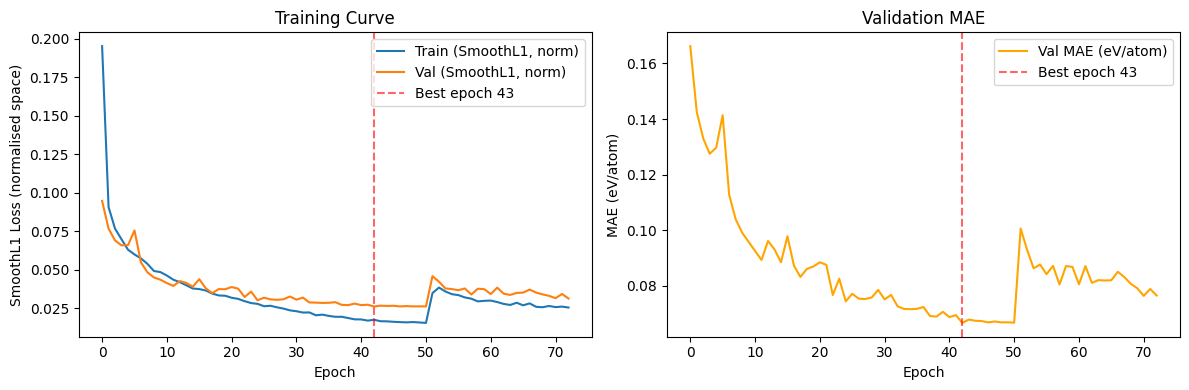

In [14]:
# ── Cell 14: Training curves ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train (SmoothL1, norm)")
axes[0].plot(val_losses,   label="Val (SmoothL1, norm)")
axes[0].axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch {best_epoch}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("SmoothL1 Loss (normalised space)")
axes[0].set_title("Training Curve")
axes[0].legend()

axes[1].plot(val_maes, label="Val MAE (eV/atom)", color="orange")
axes[1].axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch {best_epoch}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (eV/atom)")
axes[1].set_title("Validation MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=600)
plt.show()

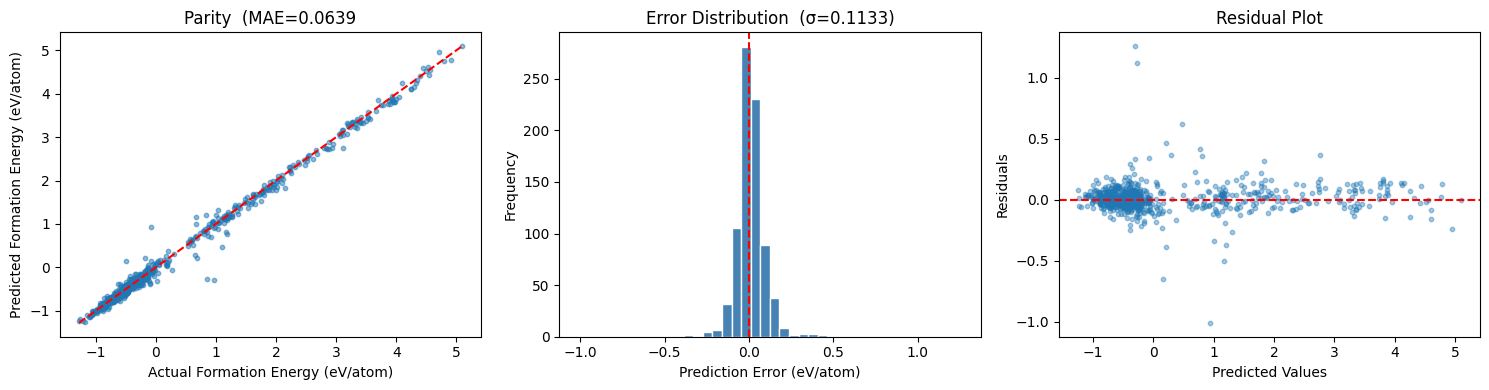

In [ ]:
# ── Cell 15: Evaluation plots ─────────────────────────────────────────────

errors = y_true_np - y_pred_np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Parity plot
lims = [min(y_true_np.min(), y_pred_np.min()), max(y_true_np.max(), y_pred_np.max())]
axes[0].scatter(y_true_np, y_pred_np, alpha=0.5, s=10)
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Formation Energy (eV/atom)")
axes[0].set_ylabel("Predicted Formation Energy (eV/atom)")
axes[0].set_title(f"Parity  (MAE={mae:.4f})")

# Error distribution
axes[1].hist(errors, bins=40, edgecolor="white", color="steelblue")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Prediction Error (eV/atom)")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Error Distribution  (σ={errors.std():.4f})")

# Residual plot
axes[2].scatter(y_pred_np, errors, alpha=0.4, s=10)
axes[2].axhline(0, color="r", linestyle="--")
axes[2].set_xlabel("Predicted Values")
axes[2].set_ylabel("Residuals")
axes[2].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=600)
plt.show()


plt.figure(); plt.scatter(y_true_np, y_pred_np, alpha=0.6)
plt.plot(lims, lims, "r--")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual")
plt.tight_layout(); plt.savefig("parity_plot.png", dpi=600); plt.close()

plt.figure(); plt.hist(errors, bins=30, edgecolor="white")
plt.xlabel("Error"); plt.ylabel("Freq")
plt.tight_layout(); plt.savefig("error_dist.png", dpi=600); plt.close()

plt.figure(); plt.scatter(y_pred_np, errors, alpha=0.6)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.tight_layout(); plt.savefig("residuals.png", dpi=600); plt.close()

In [16]:
# ── Cell 16: Save final model (SHAP/LIME/XAI compatible) ──────────────────
#
#
#   HeuGNet_final.pth  – full checkpoint with meta (target_mean/std)
#                        - use model.load_state_dict(ckpt["model_state"])
#   HeuGNet_weights.pth – state_dict only (drop-in for legacy loading code)
#
# XAI: AttentionalAggregation's gate scores are accessible after
# pooling for node-level attribution without additional wrappers.

torch.save(
    {
        "model_state" : model.state_dict(),
        "target_mean" : TARGET_MEAN,
        "target_std"  : TARGET_STD,
        "hidden_dim"  : 128,
        "emb_dim"     : 64,
        "num_blocks"  : 3,
    },
    "HeuGNet_final.pth",
)
torch.save(model.state_dict(), "HeuGNet_weights.pth")
print("Saved HeuGNet_final.pth  (full checkpoint)")
print("Saved HeuGNet_weights.pth (state_dict only)")

Saved HeuGNet_final.pth  (full checkpoint)
Saved HeuGNet_weights.pth (state_dict only)


Total nodes: torch.Size([41979, 5])


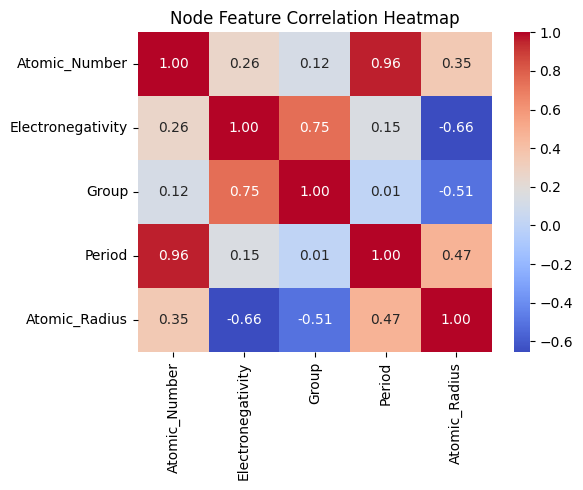

In [17]:
# ── Cell 17: Node feature correlation heatmap─────────────────

all_nodes = torch.cat([g.x for g in graphs], dim=0)
print("Total nodes:", all_nodes.shape)

# Original 5 features
feature_names = ["Atomic_Number", "Electronegativity", "Group", "Period", "Atomic_Radius"]
df_nodes    = pd.DataFrame(all_nodes.numpy(), columns=feature_names)
corr_matrix = df_nodes.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Node Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("feature_corr.png", dpi=600)
plt.show()

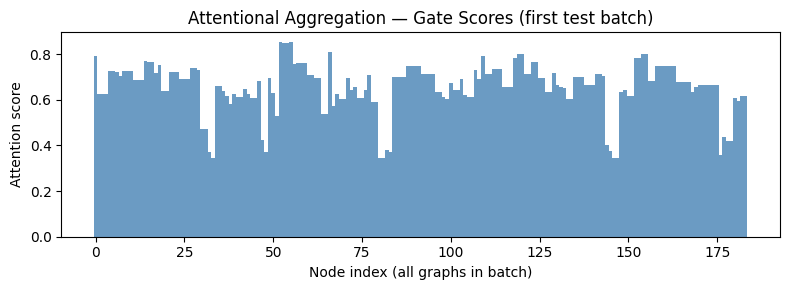

In [18]:
# ── Cell 18: Attention score visualisation
#
# The attention gate scores reveal which atoms the model focuses on for
# predicting formation energy — useful for physics interpretation.


model.eval()

# Hook to capture attention weights from the gate_nn inside pool
_attn_scores = []
_batch_ptr   = []

def _attn_hook(module, inp, out):
    _attn_scores.append(out.detach().cpu())

handle = model.pool.gate_nn.register_forward_hook(_attn_hook)

sample_data = next(iter(test_loader)).to(device)
with torch.no_grad():
    _ = model(sample_data)

handle.remove()

if _attn_scores:
    scores = torch.sigmoid(_attn_scores[0]).numpy().flatten()
    plt.figure(figsize=(8, 3))
    plt.bar(range(len(scores)), scores, width=1.0, color="steelblue", alpha=0.8)
    plt.xlabel("Node index (all graphs in batch)")
    plt.ylabel("Attention score")
    plt.title("Attentional Aggregation — Gate Scores (first test batch)")
    plt.tight_layout()
    plt.savefig("attention_scores.png", dpi=600)
    plt.show()
else:
    print("No attention scores captured — hook may need adjustment.")

In [ ]:
# To load the model use the below given syntax
"""ckpt = torch.load("HeuGNet_final.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])"""

<All keys matched successfully>